## init

In [78]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [79]:
from autoadsorbate import Surface
from ase.io import read, write

## test

In [80]:
particle = read('./test_particle.xyz')
slab = read('./test_slab.xyz')

In [81]:
# s = Surface(slab)
# s.faces

In [82]:
s = Surface(particle, mode='particle', precision=3.)
s.grid

array([[ 5.9666038 ,  5.95173031,  5.96291214],
       [ 5.11479459,  5.0999211 ,  7.11387058],
       [ 4.84085131,  4.82597781,  8.56312625],
       [ 4.56585671,  4.55098321,  9.99313732],
       [ 4.80615686,  4.79128336, 11.43277088],
       [ 5.14742605,  5.13255255, 12.85315945],
       [ 5.99547131,  5.98059782, 13.99449458],
       [ 7.19454228,  5.2304471 ,  5.24162893],
       [ 6.74213953,  4.08511838,  6.73844786],
       [ 6.42073281,  3.33780062,  8.31140696],
       [ 6.16404878,  2.81148043,  9.99313733],
       [ 6.37447355,  3.25185393, 11.69662202],
       [ 6.85091115,  4.28219051, 13.13905551],
       [ 7.27152228,  5.36097305, 14.61411972],
       [ 8.5283279 ,  4.68720007,  4.6983819 ],
       [ 8.33685295,  3.4237473 ,  6.46330038],
       [ 8.34755862,  3.24366018,  8.34386695],
       [ 8.23364554,  2.71216317,  9.99313731],
       [ 8.33599381,  3.19641073, 11.65397209],
       [ 8.39123876,  3.63861395, 13.40732615],
       [ 8.50908289,  4.6178112 , 15.357

In [83]:
from cft import Manifold

In [84]:
m = Manifold(particle, mode='particle', precision=5)

In [60]:
# m.site_df

In [85]:
# m.faces.copy()

In [161]:
from glob import glob
import numpy as np
from ase.visualize import view

In [188]:
files = glob('../examples/Cu_smash/*_*/relaxed_*.xyz')
files.sort()

ref_en_dict = {}

for file in files:

    key = file.split('/relaxed_')[-1].split('.xyz')[0]
    # print(f'{key = }')

    atoms = read(file)
    # en = atoms.info['static_energy']#
    en = atoms.get_potential_energy()
    
    ref_en_dict['grd_'+key] = en

ref_en_dict

{'grd_top0': np.float64(-8012.22314453125),
 'grd_top1': np.float64(-8312.166015625),
 'grd_top2': np.float64(-7870.5888671875),
 'grd_top3': np.float64(-7720.6923828125),
 'grd_top4': np.float64(-8015.201171875),
 'grd_top12': np.float64(-7869.8955078125),
 'grd_top13': np.float64(-7720.63720703125),
 'grd_top14': np.float64(-8014.357421875),
 'grd_top15': np.float64(-7720.73583984375),
 'grd_top16': np.float64(-7722.091796875),
 'grd_top10': np.float64(-8164.275390625),
 'grd_top6': np.float64(-8011.2099609375),
 'grd_top7': np.float64(-7723.0087890625),
 'grd_top8': np.float64(-7575.80810546875),
 'grd_top9': np.float64(-8309.9482421875)}

In [187]:
grid_atoms = read('/home/ef/Code/CFT/examples/Cu_smash/0_5/grd_top0.xyz')
grid_atoms.arrays['e_H_0']

array([-8014.04736328, -8013.97070312, -8013.44873047, ...,
       -8012.69482422, -8013.31542969, -8013.54980469], shape=(5768,))

In [176]:
view(atoms)

<Popen: returncode: None args: ['/home/ef/Code/CFT/.venv/bin/python', '-m', ...>

In [174]:
view(read('/home/ef/Code/CFT/examples/Cu_smash/naked_particle.xyz'))

<Popen: returncode: None args: ['/home/ef/Code/CFT/.venv/bin/python', '-m', ...>

In [204]:
en_naked = read('/home/ef/Code/CFT/examples/Cu_smash/naked_particle.xyz').get_potential_energy()

files = glob('../examples/Cu_smash/*_*/grd*')
files.sort()

data = {}

for file in files:

    key = file.split('/')[-1].split('.xyz')[0]
    # print(f'{key = }')
    data[key] = read(file)

for name, grid_atoms in data.items():
    if 'naked' in name:
        continue
    
    naked_atoms = data[name+'_naked']

    keys = [k for k in grid_atoms.arrays.keys()]
    for k in keys:
        if 'e_' in k and 'grad' not in k:
            
            mask = (grid_atoms.arrays[k] - np.min(grid_atoms.arrays[k])) < 2
            grid_atoms.arrays['delta_'+k] = grid_atoms.arrays[k]- ref_en_dict[name] - naked_atoms.arrays[k] + en_naked
            # grid_atoms.arrays['delta_'+k] -= np.min(grid_atoms.arrays['delta_'+k])
            # grid_atoms.arrays['delta_'+k] *= mask
            # grid_atoms.arrays['delta_'+k] += ~mask*2
            
        grid_atoms.arrays['rel_'+k] = grid_atoms.arrays[k] - np.min(grid_atoms.arrays[k])


trj = [grid_atoms for name, grid_atoms in data.items() if 'naked' not in name]


In [205]:
write('/mnt/c/Users/ef/Desktop/tmp/x.xyz', trj)

In [195]:
grid_atoms

Atoms(symbols='X5768', pbc=False, e_C_0=..., e_ClC#O+_0=..., e_ClP_0=..., e_H_0=..., e_O_0=..., grad_e_C_0=..., grad_e_ClC#O+_0=..., grad_e_ClP_0=..., grad_e_H_0=..., grad_e_O_0=..., grad_norm_e_C_0=..., grad_norm_e_ClC#O+_0=..., grad_norm_e_ClP_0=..., grad_norm_e_H_0=..., grad_norm_e_O_0=...)

In [209]:
atoms

Atoms(symbols='C280H665Cu932P35', pbc=False, anchors=..., fragments=..., momenta=..., constraint=FixAtoms(indices=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 

In [211]:
# m = Manifold(atoms[], mode='particle')

<Axes: ylabel='Density'>

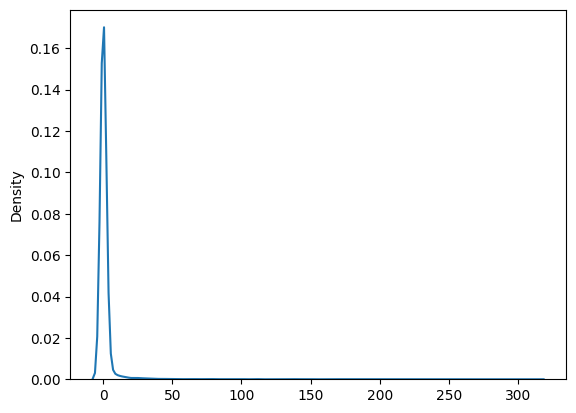

In [ ]:
sns.kdeplot(trj[0].arrays['delta_e_H_0'])

## make data for Kjell

In [216]:
rh_trj = read('/home/ef/Code/bo-adsorbate/examples/run_particle/rh_28.xyz', index=':')
len(rh_trj)

34

In [215]:
for atoms in rh_trj:
    print(atoms.get_chemical_formula())

Rh28
Rh28
Rh28
Rh28
Rh28
Rh28
Rh28
Rh28
Rh28
Rh28
Rh28
Rh28
Rh28
Rh28
Rh28
Rh28
Rh28
Rh28
Rh28
Rh28
Rh28
Rh28
Rh28
Rh28
Rh28
Rh28
Rh28
Rh28
Rh28
Rh28
Rh28
Rh28
Rh28
Rh28
